# 5.07 -- Transformer model interpretability (k-mer attribution + L1.3 domains)

Backs manuscript **Section 2.6 "Transformers Model Interpret"** and answers reviewer
**R2-Major-13**, which raised two points:

1. **Define the attribution method.** The "relevance scores" are **Layer
   Integrated Gradients** (Sundararajan et al. 2017) on the ALBERT word-embedding
   layer -- the quantity `transformers-interpret`'s `SequenceClassificationExplainer`
   computes -- **not raw attention weights**. Positive = the k-mer pushes *toward*
   the predicted LINE-1 class; negative = *against* it.
2. **Biological validation.** Map the top-attributed k-mers back to the L1.3
   consensus (L19088.1) and check whether they cluster in functional domains
   (5'UTR promoter, ORF1, ORF2 endonuclease/reverse-transcriptase).

**Stage A** (`trap/analysis/interpret.py`, on Grace -- GPU + minimap2) computes
per-token IG attribution *and* the naive last-layer attention proxy over sampled
L1HS / L1PA / NEGATIVE reads, aligns every read to L1.3, and writes
`results/interpret/{per_kmer_attribution.csv, read_examples.csv, manifest.json}`:

```bash
# seqlabel classifier (sequence-anchored labels) -- default
sbatch scripts/slurm/interpret.slurm
# then sync results/interpret/ to this machine and run Stage B below.
```

**Stage B** (this notebook) renders four figures into `reports/figures/interpret/`:

- **`relevance_heatmap`** -- per-read k-mer relevance (reproduces the manuscript
  figure, now explicitly defined as IG): green = positive, red = negative.
- **`ig_vs_attention`** -- IG attribution vs raw attention per k-mer: the two
  disagree, demonstrating attention is not a reliable importance proxy.
- **`attribution_by_consensus`** -- mean attribution along the L1.3 consensus with
  functional-domain bands; shows where high-attribution k-mers concentrate.
- **`domain_enrichment`** -- enrichment of top-decile-attribution k-mers per L1
  domain (Fisher test), written to `results/interpret/domain_enrichment.csv`.


In [1]:
## Setup, palette, helpers ----------------------------------------------------
set.seed(3469)
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
  library(jsonlite)
})
options(repr.plot.width = 14, repr.plot.height = 8)
theme_set(theme_bw(base_size = 28.125))

results_dir <- file.path("..", "results", "interpret")
figures_dir <- file.path("..", "reports", "figures", "interpret")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

# Functional L1.3 (L19088.1) regions -- must match trap/analysis/_l1_align.py.
domain_table <- data.table(
  domain = c("5UTR", "ORF1", "interORF", "ORF2_EN", "ORF2_mid", "ORF2_RT", "ORF2_C", "3UTR"),
  start  = c(1, 910, 1924, 1991, 2731, 3400, 4351, 5815),
  end    = c(909, 1923, 1990, 2730, 3399, 4350, 5814, 6100)
)
domain_table[, mid := (start + end) / 2]
domain_levels <- c(domain_table$domain, "outside", "unaligned")

# Qualitative domain palette; the reviewer-named 5'UTR promoter and ORF2-RT are
# given the two most saturated hues. Red #D62728 is reserved for reference lines.
domain_palette <- c(
  "5UTR" = "#1F77B4", "ORF1" = "#8C9EB2", "interORF" = "#C7C7C7",
  "ORF2_EN" = "#2CA02C", "ORF2_mid" = "#98DF8A", "ORF2_RT" = "#FF7F0E",
  "ORF2_C" = "#FFBB78", "3UTR" = "#9467BD", "outside" = "#D9D9D9",
  "unaligned" = "#F0F0F0"
)

save_fig <- function(plot, stem, width = 14, height = 8) {
  for (ext in c("png", "pdf")) {
    f <- file.path(figures_dir, paste0(stem, ".", ext))
    suppressMessages(ggsave(f, plot, width = width, height = height, dpi = 300, bg = "white"))
  }
  invisible(plot)
}


In [2]:
## Load Stage-A outputs + provenance ------------------------------------------
kmer_path <- file.path(results_dir, "per_kmer_attribution.csv")
ex_path   <- file.path(results_dir, "read_examples.csv")
stopifnot(
  "per_kmer_attribution.csv not found -- run scripts/slurm/interpret.slurm on Grace, then sync results/interpret/" =
    file.exists(kmer_path),
  "read_examples.csv not found -- run Stage A first" = file.exists(ex_path)
)
km  <- fread(kmer_path)
ex  <- fread(ex_path)

req <- c("read_uid", "label", "pred", "mate", "offset", "kmer",
         "attribution", "attention", "l1_pos", "domain")
stopifnot("missing required columns" = all(req %in% names(km)))
km[, domain := factor(domain, levels = domain_levels)]
km[, label  := factor(label, levels = c("L1HS", "L1PA", "NEGATIVE"))]

manifest_path <- file.path(results_dir, "manifest.json")
if (file.exists(manifest_path)) {
  manifest <- fromJSON(manifest_path)
  cat("-- provenance --\n")
  cat("git_commit:", manifest$git_commit, "\n")
  cat("attribution:", manifest$attribution$method, "\n")
  cat("  baseline:", manifest$attribution$reference_baseline,
      "| ig_steps:", manifest$attribution$ig_steps,
      "| target:", manifest$attribution$target, "\n")
  cat("  library-equivalent:", manifest$attribution$library_equivalent, "\n")
  if (!is.null(manifest$seed)) stopifnot(manifest$seed == 3469)
}
cat(sprintf("\nLoaded %d k-mers over %d reads (%d L1.3-placed).\n",
            nrow(km), uniqueN(km$read_uid), sum(km$domain != "unaligned")))
print(km[, .(kmers = .N, aligned = sum(domain != "unaligned")), by = label])


-- provenance --
git_commit: d2465ab 
attribution: Layer Integrated Gradients (word-embedding layer) 
  baseline: [PAD] (special tokens preserved) | ig_steps: 50 | target: predicted 
  library-equivalent: transformers-interpret SequenceClassificationExplainer 

Loaded 241200 k-mers over 900 reads (97418 L1.3-placed).
      label kmers aligned
     <fctr> <int>   <int>
1:     L1HS 80400   76112
2:     L1PA 80400   21306
3: NEGATIVE 80400       0


---
## Section A -- attribution method (reviewer point 1)


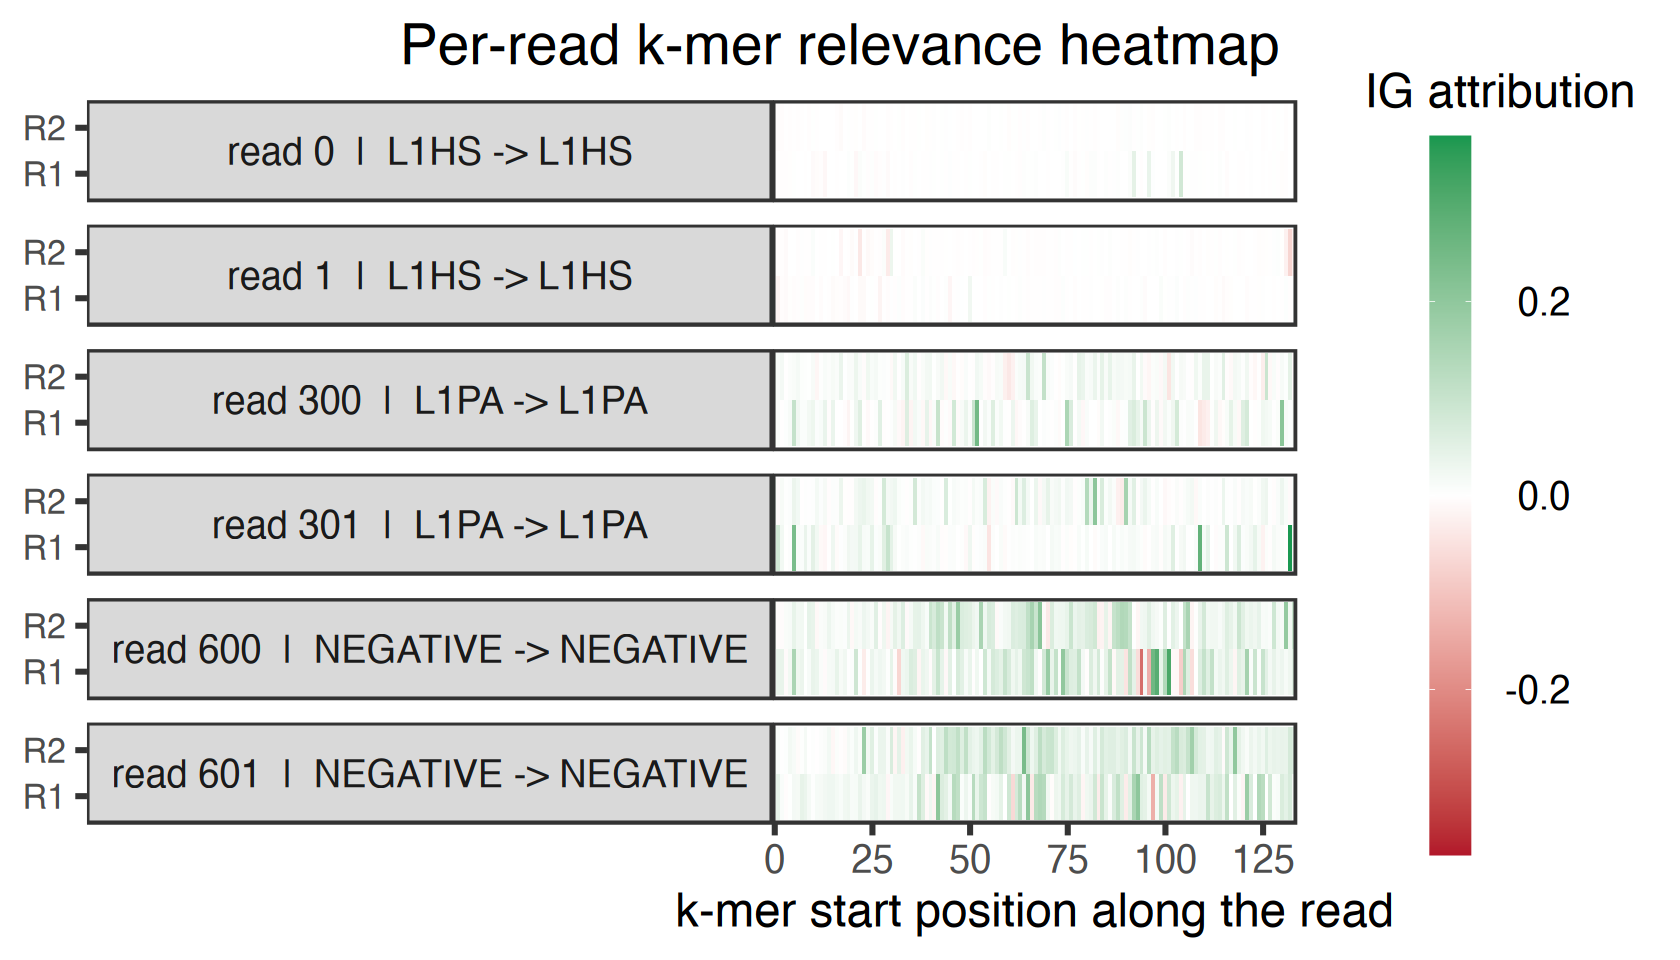

In [13]:
## Fig 1: per-read relevance heatmap (Layer Integrated Gradients) -------------------
# Reproduces the manuscript ALBERT-relevance figure, now explicitly defined as IG.
# Each tile is one k-mer position along a mate; colour = signed attribution
# (green = positive toward the predicted class, red = against). 
# Green: k-mer supports the predicted class | Red: k-mer opposes it. One facet row per
# example read (label -> prediction), split into its R1 / R2 mates.
ex[, read_tag := sprintf("read %d  |  %s -> %s", read_uid, label, pred)]
ex[, read_tag := factor(read_tag, levels = unique(read_tag[order(label, read_uid)]))]
lim <- max(abs(ex$attribution))

p_heat <- ggplot(ex, aes(offset, mate, fill = attribution)) +
  geom_tile() +
  facet_wrap(~ read_tag, ncol = 1, strip.position = "left") +
  scale_fill_gradient2(
    low = "#B2182B",
    mid = "white",
    high = "#1A9850",
    midpoint = 0,
    limits = c(-lim, lim),
    name = "IG attribution",
    guide = guide_colourbar(
      barheight = unit(6.0, "in"),
      barwidth  = unit(0.35, "in"),
      label.hjust = 1,
      ticks = FALSE
    )
  ) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(
    x = "k-mer start position along the read",
    y = NULL,
    title = "Per-read k-mer relevance heatmap"
  ) +
  theme(
    panel.grid = element_blank(),
    strip.text.y.left = element_text(angle = 0),
    legend.position = "right",
    legend.text = element_text(hjust = 1),
    legend.title = element_text(hjust = 0.5),
    axis.text.y = element_text(size = 20),

    # Make title use the full plot width
    plot.title.position = "plot",
    plot.title = element_text(hjust = 0.5)
  )

save_fig(p_heat, "relevance_heatmap", width = 16, height = 9)
p_heat


In [4]:
## Table: top positively- and negatively-attributed k-mers -------------------
# The manuscript lists example high/low k-mers; regenerate them from the attribution
# table (positive-class reads only), collapsing repeats to mean attribution.
pos_reads <- km[label %in% c("L1HS", "L1PA")]
kmer_rank <- pos_reads[, .(mean_attr = mean(attribution), n = .N,
                           domain = domain[which.max(abs(attribution))]),
                        by = kmer][n >= 2]
top_pos <- head(kmer_rank[order(-mean_attr)], 12)
top_neg <- head(kmer_rank[order(mean_attr)], 12)
cat("Top positively-attributed k-mers (support LINE-1):\n"); print(top_pos)
cat("\nTop negatively-attributed k-mers (oppose LINE-1):\n"); print(top_neg)
fwrite(rbind(cbind(sign = "positive", top_pos), cbind(sign = "negative", top_neg)),
       file.path(results_dir, "top_kmers.csv"))


Top positively-attributed k-mers (support LINE-1):
                 kmer mean_attr     n    domain
               <char>     <num> <int>    <fctr>
 1: AAAATGCTCATCATCAC 0.5388295     5    ORF2_C
 2: ATATGCACCCAATACAG 0.5362999     2   ORF2_EN
 3: ACCAGGCCTGCCTTACA 0.5093242     2 unaligned
 4: TAATTGCCCTGGCCAGA 0.4568347     2   ORF2_RT
 5: AAAAAACACATGAAAAA 0.4219227     3    ORF2_C
 6: TGAAGTCCTTGCCCATG 0.3860069     2    ORF2_C
 7: TTATCCATTTCTTCTAG 0.3834749     2  ORF2_mid
 8: ACTCTACAAGCCAGAAG 0.3767596     4      ORF1
 9: CTGTTTGTTAGTTTTCC 0.3755619     3      5UTR
10: CTAGAAGAAATGGATAA 0.3642547     2  ORF2_mid
11: CTTGGTTCCATTCTCCC 0.3607176     6      ORF1
12: TGTAGTTGAGTGGTTTT 0.3483328     2   ORF2_EN

Top negatively-attributed k-mers (oppose LINE-1):
                 kmer   mean_attr     n    domain
               <char>       <num> <int>    <fctr>
 1: AAACTGCATCAACTAAT -0.24353607     4 unaligned
 2: TGCCACATATCTACAAC -0.20002209     3    ORF2_C
 3: TTGGAGTTGCACTTCTC -0.1

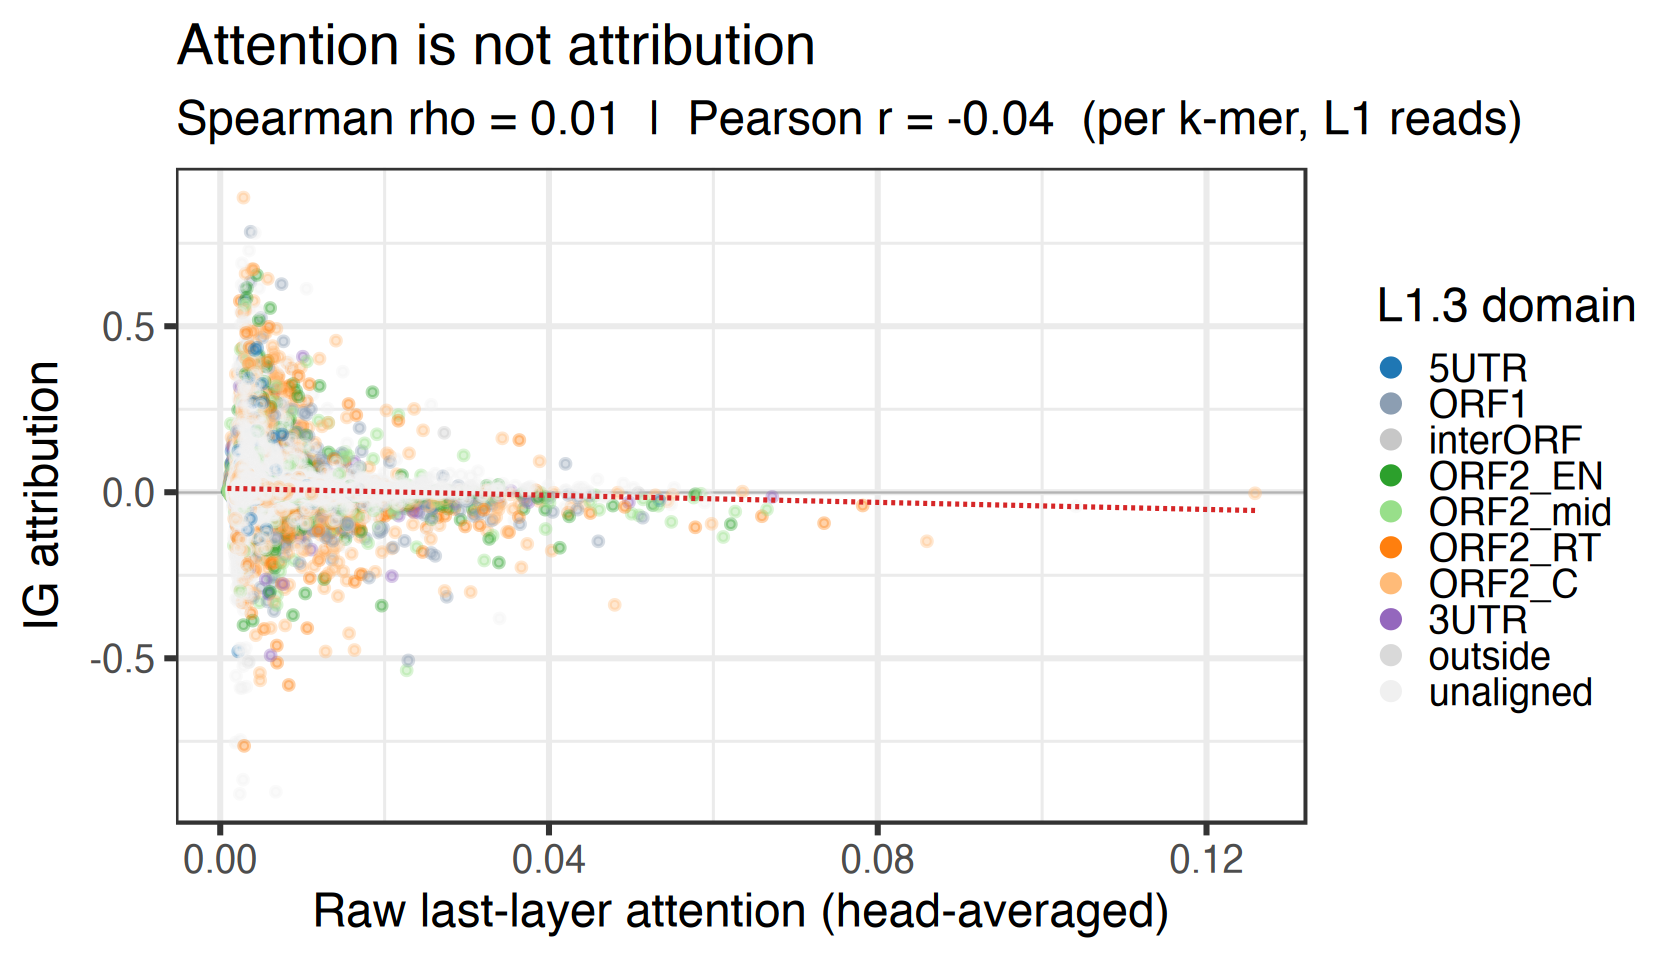

In [5]:
## Fig 2: IG attribution vs raw attention (they disagree) --------------------
# Reviewer R2-Major-13: raw attention is not a reliable importance proxy. Plot the
# naive last-layer attention (head-averaged, received per token) against the IG
# attribution for every k-mer; a weak/near-zero correlation is the evidence.
contrast <- km[label %in% c("L1HS", "L1PA")]
rho_s <- cor(contrast$attention, contrast$attribution, method = "spearman")
rho_p <- cor(contrast$attention, contrast$attribution, method = "pearson")

p_contrast <- ggplot(contrast, aes(attention, attribution)) +
  geom_hline(yintercept = 0, color = "grey70", linewidth = 0.5) +
  geom_point(aes(color = domain), alpha = 0.35, size = 1.6) +
  geom_smooth(method = "lm", formula = y ~ x, se = FALSE,
              color = "#D62728", linewidth = 1.1, linetype = "dashed") +
  scale_color_manual(values = domain_palette, name = "L1.3 domain", drop = FALSE) +
  labs(x = "Raw last-layer attention (head-averaged)", y = "IG attribution",
       title = "Attention is not attribution",
       subtitle = sprintf("Spearman rho = %.2f  |  Pearson r = %.2f  (per k-mer, L1 reads)",
                          rho_s, rho_p)) +
  guides(color = guide_legend(override.aes = list(alpha = 1, size = 4))) +
  theme(legend.position = "right")
save_fig(p_contrast, "ig_vs_attention", width = 14, height = 8)
p_contrast


---
## Section B -- biological validation on L1.3 (reviewer point 2)


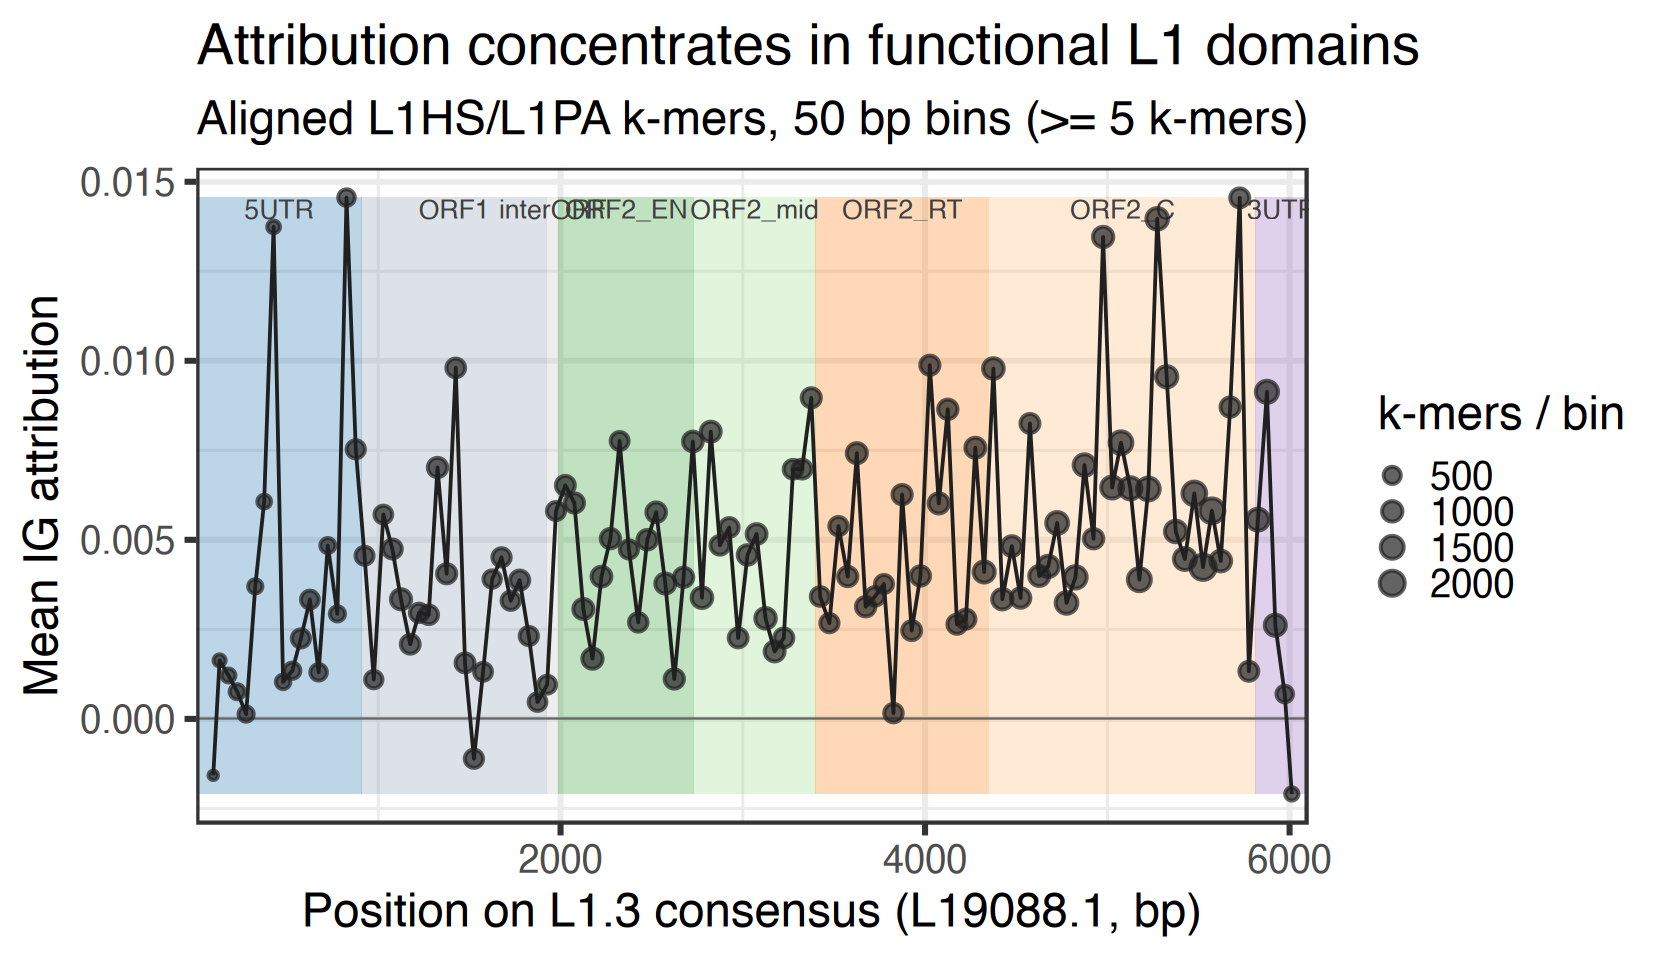

In [6]:
## Fig 3: attribution profile along the L1.3 consensus -----------------------
# Bin aligned positive-class k-mers by L1.3 coordinate (50 bp) and show mean
# attribution per bin, with functional-domain bands behind. High-attribution bins
# concentrate in specific domains rather than being spread uniformly.
aligned <- km[label %in% c("L1HS", "L1PA") & domain != "unaligned" & !is.na(l1_pos)]
aligned[, bin := cut(l1_pos, breaks = seq(0, 6100, by = 50), labels = FALSE)]
prof <- aligned[, .(mean_attr = mean(attribution), n = .N,
                    pos = mean(l1_pos)), by = bin][n >= 5]

band_y <- range(c(prof$mean_attr, 0))
bands <- copy(domain_table)[domain %in% aligned$domain]

p_prof <- ggplot() +
  geom_rect(data = bands,
            aes(xmin = start, xmax = end, ymin = band_y[1], ymax = band_y[2], fill = domain),
            alpha = 0.30) +
  geom_text(data = bands, aes(x = mid, y = band_y[2], label = domain),
            vjust = 1.1, size = 5.5, color = "grey25") +
  geom_hline(yintercept = 0, color = "grey40", linewidth = 0.5) +
  geom_line(data = prof, aes(pos, mean_attr), color = "#202020", linewidth = 0.8) +
  geom_point(data = prof, aes(pos, mean_attr, size = n), color = "#202020", alpha = 0.7) +
  scale_fill_manual(values = domain_palette, guide = "none") +
  scale_size_continuous(range = c(1.5, 6), name = "k-mers / bin") +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Position on L1.3 consensus (L19088.1, bp)", y = "Mean IG attribution",
       title = "Attribution concentrates in functional L1 domains",
       subtitle = "Aligned L1HS/L1PA k-mers, 50 bp bins (>= 5 k-mers)") +
  theme(legend.position = "right")
save_fig(p_prof, "attribution_by_consensus", width = 16, height = 8)
p_prof


     domain     n n_top enrichment  p_value    sig
     <fctr> <int> <int>      <num>    <num> <fctr>
1:     5UTR  5337   365       0.68 1.00e+00     ns
2:     ORF1 13914  1274       0.92 1.00e+00     ns
3: interORF   842    58       0.69 9.99e-01     ns
4:  ORF2_EN 12001  1031       0.86 1.00e+00     ns
5: ORF2_mid 11213  1055       0.94 9.88e-01     ns
6:  ORF2_RT 15192  1568       1.03 7.81e-02     ns
7:   ORF2_C 34864  4028       1.16 3.35e-33    ***
8:     3UTR  3994   357       0.89 9.90e-01     ns


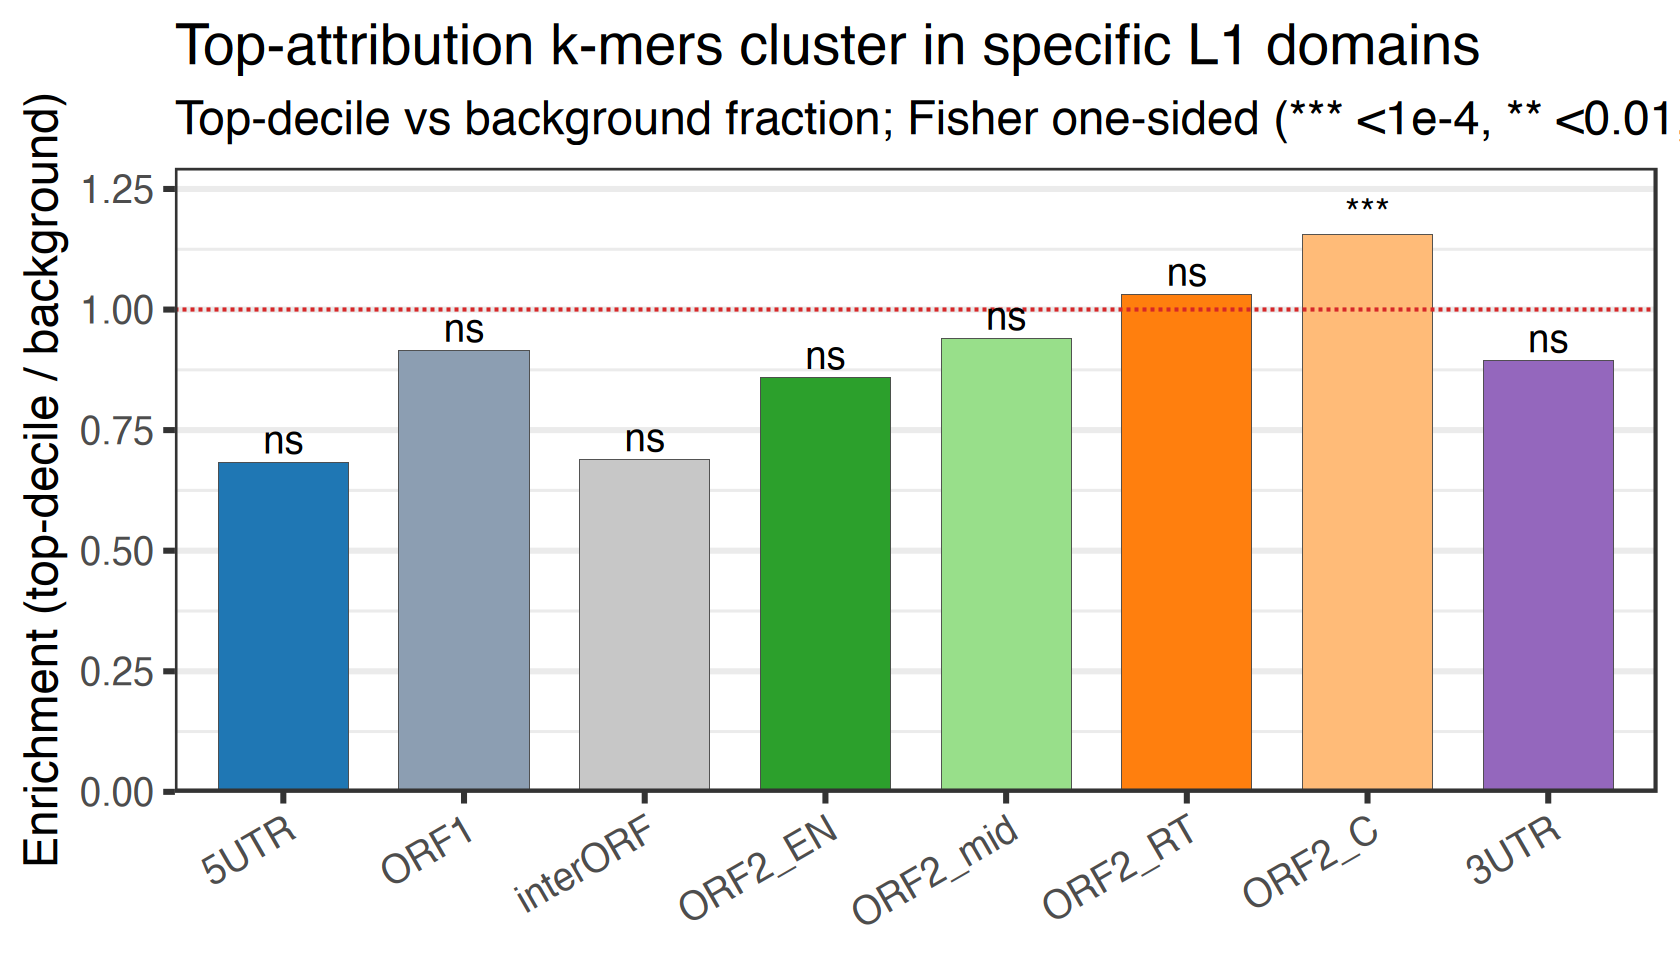

In [7]:
## Fig 4 + table: domain enrichment of top-attribution k-mers ----------------
# Are high-attribution k-mers over-represented in specific domains? Take the top
# attribution decile among aligned positive-class k-mers and, per domain, test
# top-vs-rest x in-domain-vs-out with a one-sided Fisher exact test. Enrichment =
# observed top fraction / background fraction in that domain.
aligned_dom <- aligned[domain %in% domain_table$domain]
aligned_dom[, domain := droplevels(factor(domain, levels = domain_levels))]
thr <- quantile(aligned_dom$attribution, 0.90)
aligned_dom[, is_top := attribution >= thr]

enrich <- aligned_dom[, {
  a <- sum(is_top); b <- sum(!is_top)
  .(n = .N, n_top = a)
}, by = domain]
tot_top <- sum(enrich$n_top); tot <- sum(enrich$n)
enrich[, bg_frac := n / tot]
enrich[, top_frac := n_top / tot_top]
enrich[, enrichment := top_frac / bg_frac]
enrich[, p_value := {
  vapply(seq_len(.N), function(i) {
    inside_top <- n_top[i]; inside_tot <- n[i]
    m <- matrix(c(inside_top, tot_top - inside_top,
                  inside_tot - inside_top, (tot - inside_tot) - (tot_top - inside_top)),
                nrow = 2)
    fisher.test(m, alternative = "greater")$p.value
  }, numeric(1))
}]
enrich[, domain := factor(domain, levels = domain_table$domain)]
enrich <- enrich[order(domain)]
enrich[, sig := cut(p_value, c(-Inf, 1e-4, 1e-2, 0.05, Inf),
                    labels = c("***", "**", "*", "ns"))]
print(enrich[, .(domain, n, n_top, enrichment = round(enrichment, 2),
                 p_value = signif(p_value, 3), sig)])
fwrite(enrich, file.path(results_dir, "domain_enrichment.csv"))

p_enrich <- ggplot(enrich, aes(domain, enrichment, fill = domain)) +
  geom_col(color = "grey30", linewidth = 0.2, width = 0.72) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "#D62728", linewidth = 0.9) +
  geom_text(aes(label = sig), vjust = -0.3, size = 8) +
  scale_fill_manual(values = domain_palette, guide = "none") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.12))) +
  labs(x = NULL, y = "Enrichment (top-decile / background)",
       title = "Top-attribution k-mers cluster in specific L1 domains",
       subtitle = "Top-decile vs background fraction; Fisher one-sided (*** <1e-4, ** <0.01, * <0.05)") +
  theme(axis.text.x = element_text(angle = 30, hjust = 1),
        panel.grid.major.x = element_blank())
save_fig(p_enrich, "domain_enrichment", width = 16, height = 8)
p_enrich
